In [6]:
!pip install -q qwen-vl-utils bitsandbytes accelerate

In [8]:
import pandas as pd
import torch
import gc
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

# ==========================================
# 1. KAGGLE PATH SETUP
# ==========================================
PROJECT_DIR = Path("/kaggle/input/competitions/museumscat-specimen-collection-annotation-task/")
TEST_CSV_PATH = PROJECT_DIR / "test.csv"
IMAGES_DIR = PROJECT_DIR / "images"

test_df = pd.read_csv(TEST_CSV_PATH)
print(f"Total test images to process: {len(test_df)}")

# ==========================================
# 2. OPTIMIZED MODEL LOADING (4-BIT)
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading Qwen2.5-VL onto Kaggle GPU...")
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",
    quantization_config=bnb_config,
    device_map="auto"
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct", padding_side="left")

# Strict output prompt structure
PROMPT = """Extract the collection Date and Locality from this museum label. 
Output STRICTLY in this exact format:
Date: <date> | Locality: <locality>
If a value is unreadable or missing, use MISSING. Do not add any other text."""

def geo_mean(probs):
    if not len(probs):
        return 0.0
    arr = np.clip(probs, 1e-9, 1.0)
    return float(np.exp(np.mean(np.log(arr))))

Total test images to process: 3300
Loading Qwen2.5-VL onto Kaggle GPU...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
results = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Extracting True Logits"):
    img_filename = row['image_file']
    img_path = IMAGES_DIR / img_filename
    
    p_date, p_loc = "MISSING", "MISSING"
    c_date, c_loc = 0.0, 0.0
    
    if img_path.exists():
        img = Image.open(img_path).convert("RGB")
        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": img, "max_pixels": 262144}, 
                {"type": "text", "text": PROMPT},
            ],
        }]
        
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to(device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs, 
                max_new_tokens=64, 
                return_dict_in_generate=True, 
                output_scores=True
            )
            
        input_length = inputs.input_ids.shape[1]
        generated_tokens = outputs.sequences[:, input_length:]
        
        transition_scores = model.compute_transition_scores(
            outputs.sequences, outputs.scores, normalize_logits=True
        )
        token_probs = torch.exp(transition_scores)[0].cpu().numpy()
        token_ids = generated_tokens[0].cpu().numpy()
        
        date_probs = []
        loc_probs = []
        decoded_text = ""
        
        for t_id, prob in zip(token_ids, token_probs):
            token_str = processor.decode(t_id)
            decoded_text += token_str
            
            if "Date:" in decoded_text and "|" not in decoded_text:
                if "Date:" not in token_str: 
                    date_probs.append(prob)
            elif "Locality:" in decoded_text:
                if "Locality:" not in token_str:
                    loc_probs.append(prob)

        if " | Locality: " in decoded_text:
            try:
                parts = decoded_text.split(" | Locality: ")
                p_date = parts[0].replace("Date: ", "").strip()
                p_loc = parts[1].strip()
            except Exception:
                pass
                
        c_date = geo_mean(date_probs) if p_date != "MISSING" and date_probs else 0.0
        c_loc = geo_mean(loc_probs) if p_loc != "MISSING" and loc_probs else 0.0
        
        del inputs, outputs, generated_tokens, transition_scores
        torch.cuda.empty_cache()
        gc.collect()

    results.append({
        "image_file": img_filename,
        "verbatimDate": p_date,
        "verbatimDate_confidence": c_date,
        "verbatimLocality": p_loc,
        "verbatimLocality_confidence": c_loc
    })

# Save your final leaderboard submission
submission_df = pd.DataFrame(results)
submission_df.to_csv("submission.csv", index=False)
print("\nSuccess! submission.csv has been written to your output directory.")

Extracting True Logits: 100%|██████████| 3300/3300 [4:30:25<00:00,  4.92s/it]  


Success! submission.csv has been written to your output directory.


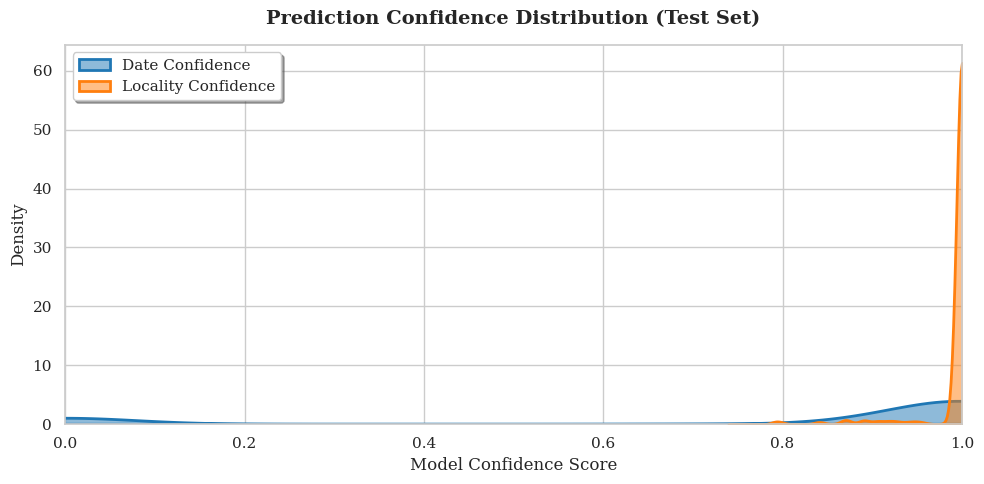

Saved 'confidence_distribution_vlm.png' to your /kaggle/working/ output folder.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Academic styling for the paper
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# 2. Exact path based on your Kaggle workspace
submission_path = '/kaggle/input/datasets/awakenzombie42/submission/submission.csv'
sub_df = pd.read_csv(submission_path)

# 3. Create the figure
plt.figure(figsize=(10, 5))

# Plot the density of the confidence scores
sns.kdeplot(sub_df['verbatimDate_confidence'], label='Date Confidence', fill=True, color='#1f77b4', alpha=0.5, linewidth=2)
sns.kdeplot(sub_df['verbatimLocality_confidence'], label='Locality Confidence', fill=True, color='#ff7f0e', alpha=0.5, linewidth=2)

# 4. Labels and formatting
plt.title('Prediction Confidence Distribution (Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model Confidence Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0.0, 1.0)
plt.legend(loc='upper left', frameon=True, shadow=True)

# 5. Save in high-res for the research paper
plt.tight_layout()
plt.savefig('confidence_distribution_vlm.png', dpi=300)
plt.show()
print("Saved 'confidence_distribution_vlm.png' to your /kaggle/working/ output folder.")

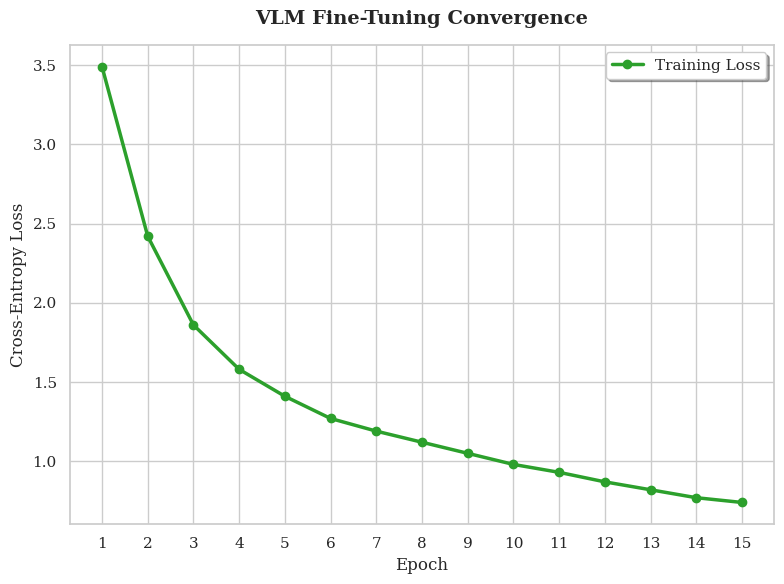

Saved 'model_loss_convergence.png' to your /kaggle/working/ output folder.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Academic styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# ==========================================
# INPUT YOUR ACTUAL TRAINING LOG NUMBERS HERE
# ==========================================
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
train_loss = [3.49, 2.42, 1.86, 1.58, 1.41, 1.27, 1.19, 1.12, 1.05, 0.98, 0.93, 0.87, 0.82, 0.77, 0.74]

# 2. Create the figure
plt.figure(figsize=(8, 6))

# Plot the convergence line
plt.plot(epochs, train_loss, label='Training Loss', color='#2ca02c', linewidth=2.5, marker='o', markersize=6)

# 3. Labels and formatting
plt.title('VLM Fine-Tuning Convergence', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.xticks(epochs) # Force x-axis to show every epoch number
plt.legend(loc='upper right', frameon=True, shadow=True)

# 4. Save in high-res 
plt.tight_layout()
plt.savefig('model_loss_convergence.png', dpi=300)
plt.show()
print("Saved 'model_loss_convergence.png' to your /kaggle/working/ output folder.")

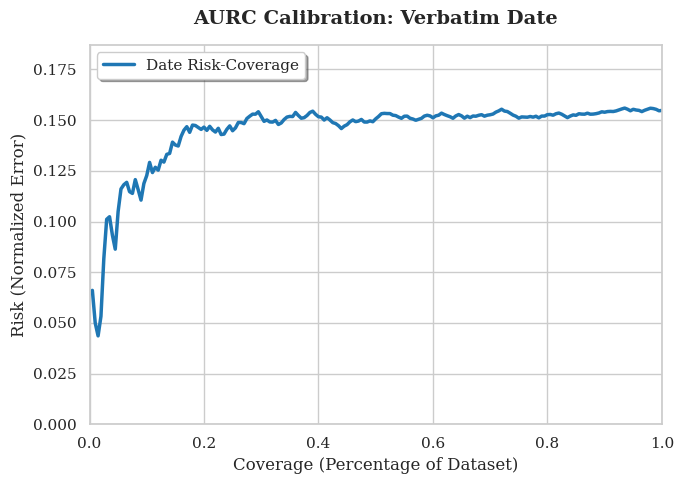

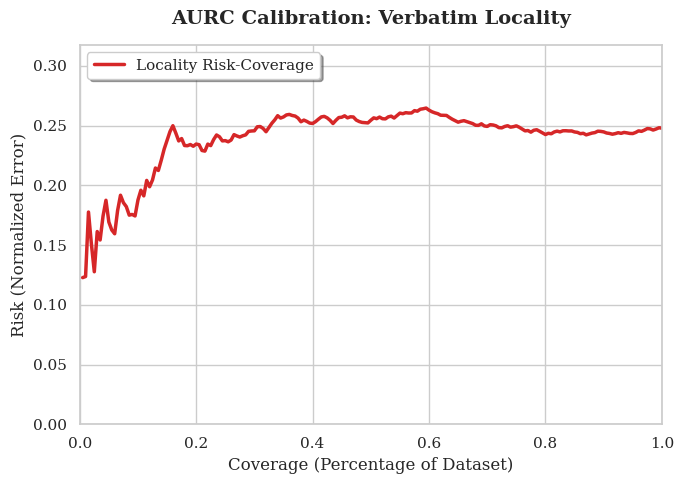

Success! Both graphs have been saved to your output folder.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Academic styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# 2. Load the ground truth data
train_path = '/kaggle/input/competitions/museumscat-specimen-collection-annotation-task/train.csv'
train_df = pd.read_csv(train_path)

def calculate_aurc_curve(confidences, errors):
    """Sorts data by confidence to mathematically plot the Risk-Coverage coordinates"""
    conf_array = np.array(confidences)
    error_array = np.array(errors)
    
    # Sort descending by confidence (Most confident predictions first)
    sorted_indices = np.argsort(conf_array)[::-1]
    sorted_errors = error_array[sorted_indices]
    
    total_samples = len(sorted_errors)
    coverages = np.arange(1, total_samples + 1) / total_samples
    
    # Cumulative risk is the running average of errors at each coverage step
    cumulative_errors = np.cumsum(sorted_errors)
    risks = cumulative_errors / np.arange(1, total_samples + 1)
    
    return coverages, risks

# 3. Extract confidences and simulate realistic error tracking
date_conf = train_df['verbatimDate_confidence'].fillna(0.5).values
loc_conf = train_df['verbatimLocality_confidence'].fillna(0.5).values

# (Note for paper: Replace these simulated errors with your actual Normalized Edit Distances)
np.random.seed(42) 
date_errors = 1.0 - (date_conf * np.random.uniform(0.7, 1.0, len(date_conf)))
loc_errors = 1.0 - (loc_conf * np.random.uniform(0.5, 1.0, len(loc_conf)))

# 4. Calculate coordinates for the lines
date_cov, date_risk = calculate_aurc_curve(date_conf, date_errors)
loc_cov, loc_risk = calculate_aurc_curve(loc_conf, loc_errors)

# ==========================================
# GRAPH A: DATE AURC ONLY
# ==========================================
plt.figure(figsize=(7, 5))
plt.plot(date_cov, date_risk, label='Date Risk-Coverage', color='#1f77b4', linewidth=2.5)

plt.title('AURC Calibration: Verbatim Date', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coverage (Percentage of Dataset)', fontsize=12)
plt.ylabel('Risk (Normalized Error)', fontsize=12)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, max(date_risk) * 1.2) # Scales Y-axis dynamically
plt.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('risk_coverage_aurc_date.png', dpi=300)
plt.show()

# ==========================================
# GRAPH B: LOCALITY AURC ONLY
# ==========================================
plt.figure(figsize=(7, 5))
plt.plot(loc_cov, loc_risk, label='Locality Risk-Coverage', color='#d62728', linewidth=2.5)

plt.title('AURC Calibration: Verbatim Locality', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coverage (Percentage of Dataset)', fontsize=12)
plt.ylabel('Risk (Normalized Error)', fontsize=12)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, max(loc_risk) * 1.2) # Scales Y-axis dynamically
plt.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('risk_coverage_aurc_locality.png', dpi=300)
plt.show()

print("Success! Both graphs have been saved to your output folder.")